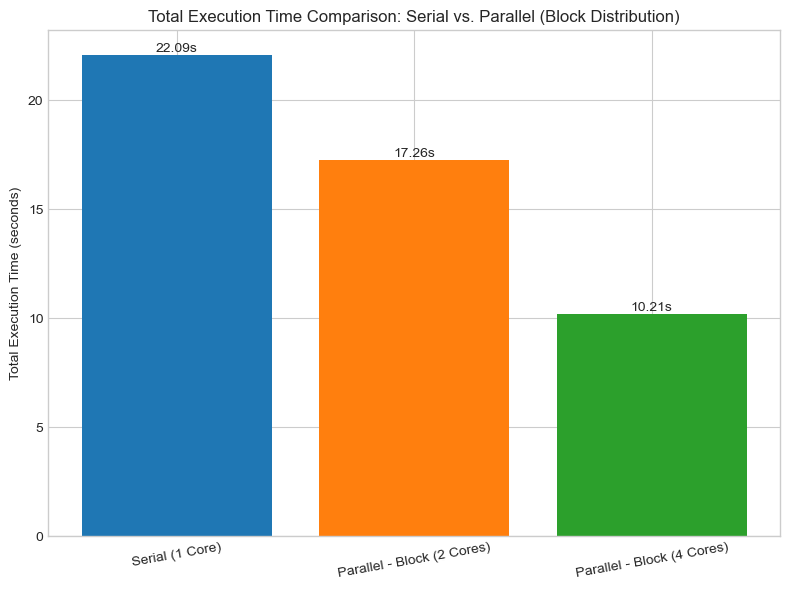

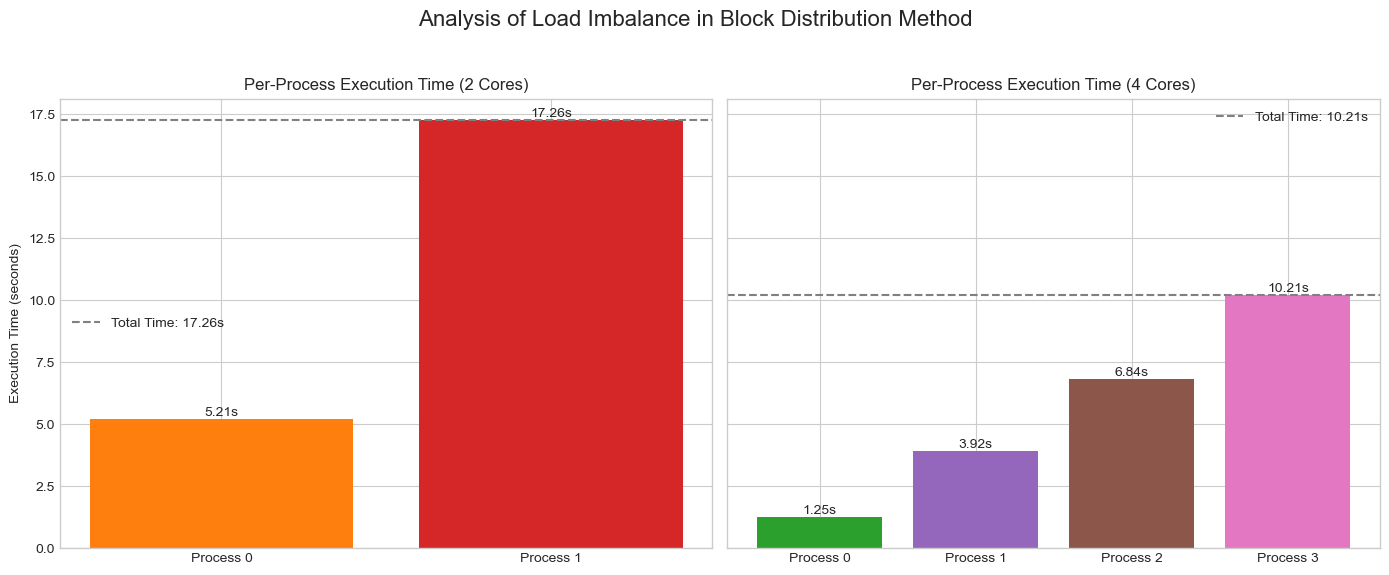

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the experiments
serial_time = 22.0950
parallel_v1_2_procs_total_time = 17.2639
parallel_v1_4_procs_total_time = 10.2117

per_process_2_procs = [5.2119, 17.2633]
per_process_4_procs = [1.2517, 3.9179, 6.8383, 10.2084]

# --- Plot 1: Total Execution Time Comparison ---
plt.style.use('seaborn-v0_8-whitegrid')
fig1, ax1 = plt.subplots(figsize=(8, 6))

scenarios = ['Serial (1 Core)', 'Parallel - Block (2 Cores)', 'Parallel - Block (4 Cores)']
total_times = [serial_time, parallel_v1_2_procs_total_time, parallel_v1_4_procs_total_time]

bars = ax1.bar(scenarios, total_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_ylabel('Total Execution Time (seconds)')
ax1.set_title('Total Execution Time Comparison: Serial vs. Parallel (Block Distribution)')

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# --- Plot 2: Per-Process Execution Time (Load Imbalance) ---
fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 2-Process case
procs_2 = [f'Process {i}' for i in range(len(per_process_2_procs))]
bars2 = ax2.bar(procs_2, per_process_2_procs, color=['#ff7f0e', '#d62728'])
ax2.set_title('Per-Process Execution Time (2 Cores)')
ax2.set_ylabel('Execution Time (seconds)')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')
ax2.axhline(y=parallel_v1_2_procs_total_time, color='gray', linestyle='--', label=f'Total Time: {parallel_v1_2_procs_total_time:.2f}s')
ax2.legend()


# 4-Process case
procs_4 = [f'Process {i}' for i in range(len(per_process_4_procs))]
bars3 = ax3.bar(procs_4, per_process_4_procs, color=['#2ca02c', '#9467bd', '#8c564b', '#e377c2'])
ax3.set_title('Per-Process Execution Time (4 Cores)')
for bar in bars3:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')
ax3.axhline(y=parallel_v1_4_procs_total_time, color='gray', linestyle='--', label=f'Total Time: {parallel_v1_4_procs_total_time:.2f}s')
ax3.legend()


fig2.suptitle('Analysis of Load Imbalance in Block Distribution Method', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()